<a href="https://colab.research.google.com/github/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/blob/main/Literature%20Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Literature Review**

**Source 1: Kaggle: Industrial Safety & Health Analytics Database (IHM Stefanini). Dataset page and schema. (Kaggle)**

12 different plants in 03 different countries

Accident level:

      I = not severe
      VI = very sever




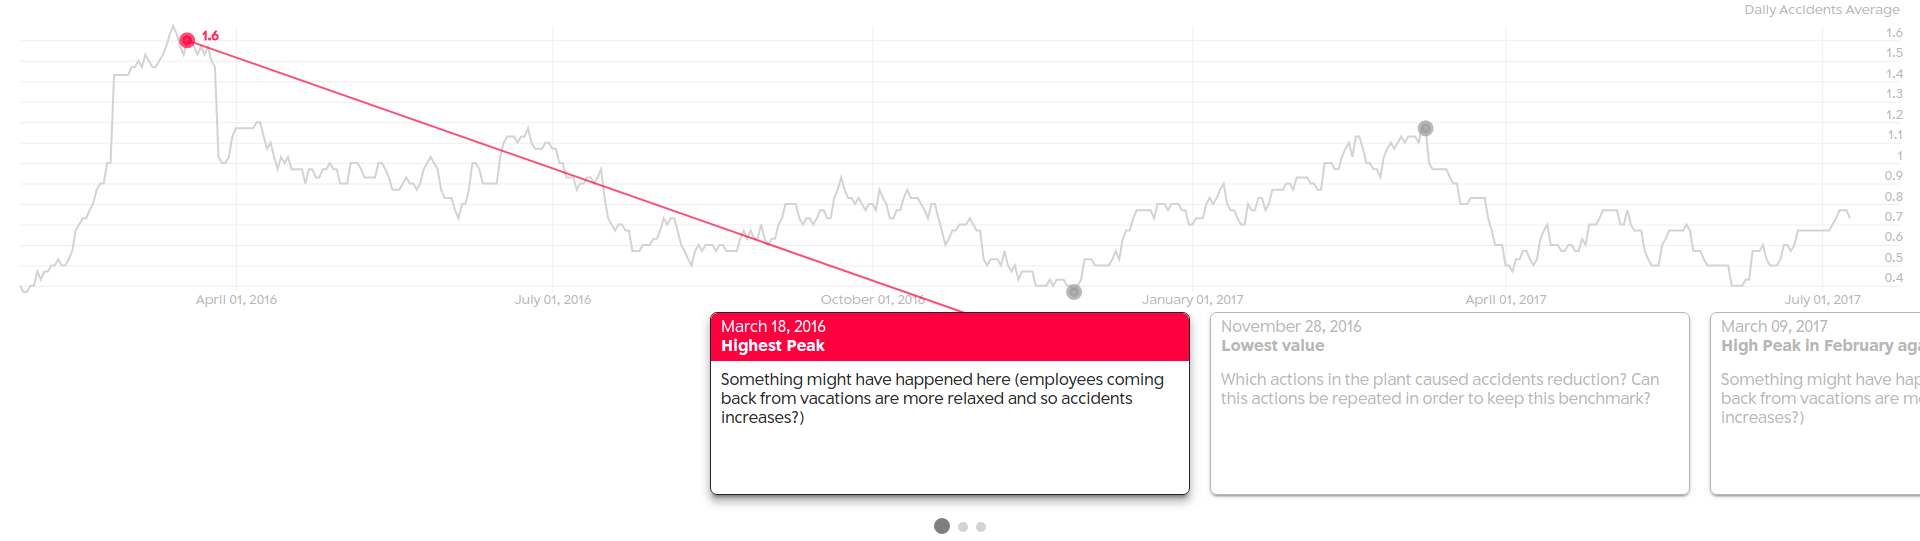

The above imae show a prior analysis cqarried out using the steffeni's data set and few predictions and analytical results obtained. this analysis is based on the date of accidents.

**Source 2: Community example: “Industrial Safety & Health Analytics — EDA” (Kaggle notebook). (Kaggle)**

Mainly EDA: Exploratory Data Analysis (a method to understand data patterns) has done in this article to understand different kinds of pattern throghout the the data set

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

data_set_1 = pd.read_csv("https://raw.githubusercontent.com/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/main/IHMStefanini_industrial_safety_and_health_database.csv")
data_set_2 = pd.read_csv("https://raw.githubusercontent.com/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/main/IHMStefanini_industrial_safety_and_health_database_with_accidents_description.csv")

In [10]:
data_set_1.info() #summary of the variables and data set 1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439 entries, 0 to 438
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Data                      439 non-null    object
 1   Countries                 439 non-null    object
 2   Local                     439 non-null    object
 3   Industry Sector           439 non-null    object
 4   Accident Level            439 non-null    object
 5   Potential Accident Level  439 non-null    object
 6   Genre                     439 non-null    object
 7   Employee ou Terceiro      439 non-null    object
 8   Risco Critico             439 non-null    object
dtypes: object(9)
memory usage: 31.0+ KB


In [11]:
data_set_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                425 non-null    int64  
 1   Data                      425 non-null    object 
 2   Countries                 425 non-null    object 
 3   Local                     425 non-null    object 
 4   Industry Sector           425 non-null    object 
 5   Accident Level            425 non-null    object 
 6   Potential Accident Level  425 non-null    object 
 7   Genre                     425 non-null    object 
 8   Employee or Third Party   425 non-null    object 
 9   Critical Risk             425 non-null    object 
 10  Description               425 non-null    object 
 11  Unnamed: 11               0 non-null      float64
dtypes: float64(1), int64(1), object(10)
memory usage: 40.0+ KB


In [6]:
data_set_1.head() #to go through what kind of data is recorded normally

,Data,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee ou Terceiro,Risco Critico
0,1/1/2016 0:00,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed
1,1/2/2016 0:00,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems
2,1/6/2016 0:00,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools
3,1/8/2016 0:00,Country_01,Local_04,Mining,I,I,Male,Third Party,Others
4,1/10/2016 0:00,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others


Here, i have found out that all the coloumn names do not exactly represent the type the record it is holding. hence, a renaming is requred.

    Data                    --->  Date
    Genre                   --->  Gender
    Employee ou Terceiro    --->  Employee or Third party
    Risco Critico           --->  Critical Risk

In [20]:
data_set_1.rename(columns={"Genre": "Gender", "Data": "Date","Employee ou Terceiro":"Employee or Third party","Risco Critico":"Critical Risk"}, inplace=True)
data_set_1['Date']= pd.to_datetime(data_set_1['Date'])

In [19]:
data_set_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439 entries, 0 to 438
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      439 non-null    datetime64[ns]
 1   Countries                 439 non-null    object        
 2   Local                     439 non-null    object        
 3   Industry Sector           439 non-null    object        
 4   Accident Level            439 non-null    object        
 5   Potential Accident Level  439 non-null    object        
 6   Gender                    439 non-null    object        
 7   Employee or Third party   439 non-null    object        
 8   Critical Risk             439 non-null    object        
dtypes: datetime64[ns](1), object(8)
memory usage: 31.0+ KB


In [22]:
data_set_2.head()

,Unnamed: 0,Date,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Gender,Employee or Third Party,Critical Risk,Description,Unnamed: 11
0,0,2016-01-01,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...,NaN
1,1,2016-01-02,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...,NaN
2,2,2016-01-06,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools,In the sub-station MILPO located at level +170...,NaN
3,3,2016-01-08,Country_01,Local_04,Mining,I,I,Male,Third Party,Others,Being 9:45 am. approximately in the Nv. 1880 C...,NaN
4,4,2016-01-10,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others,Approximately at 11:45 a.m. in circumstances t...,NaN


Here, i have also found out that all the coloumn names do not exactly represent the type the record it is holding in data set 2. hence, a renaming is requred.

    Data                    --->  Date
    Genre                   --->  Gender

In [35]:
data_set_2.rename(columns={"Genre": "Gender", "Data": "Date"}, inplace=True)
data_set_2['Date']= pd.to_datetime(data_set_2['Date'])
#data_set_2.drop(labels="Unnamed: 11",axis=1,inplace=True)
data_set_2.drop(labels="Unnamed: 0",axis=1,inplace=True)

In [36]:
data_set_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      425 non-null    datetime64[ns]
 1   Countries                 425 non-null    object        
 2   Local                     425 non-null    object        
 3   Industry Sector           425 non-null    object        
 4   Accident Level            425 non-null    object        
 5   Potential Accident Level  425 non-null    object        
 6   Gender                    425 non-null    object        
 7   Employee or Third Party   425 non-null    object        
 8   Critical Risk             425 non-null    object        
 9   Description               425 non-null    object        
dtypes: datetime64[ns](1), object(9)
memory usage: 33.3+ KB


In [16]:
data_set_2["Accident Level"].value_counts()

,count
Accident Level,
I,316
II,40
III,31
IV,30
V,8


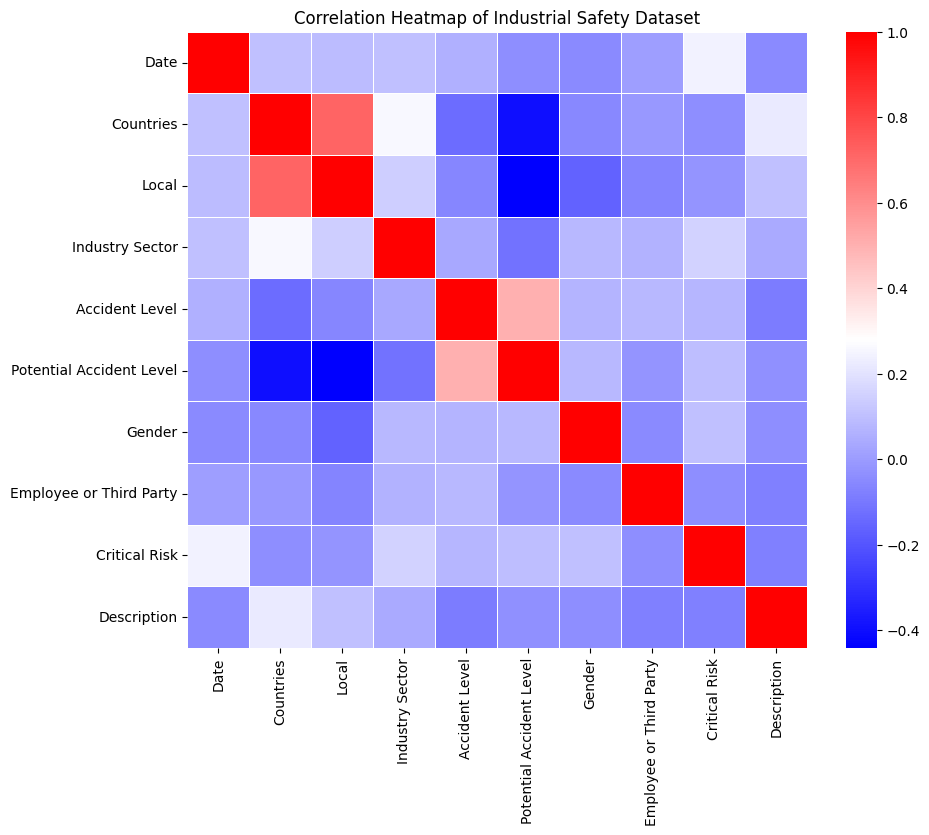

In [37]:
data_encoded = data_set_2.copy()

for col in data_encoded.columns:
    data_encoded[col] = data_encoded[col].astype('category').cat.codes

corr_matrix = data_encoded.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    cmap="bwr",       # blue-white-red like your image
    annot=False,      # no numbers inside
    linewidths=0.5
)
plt.title("Correlation Heatmap of Industrial Safety Dataset")
plt.show()


Now let's generate few gaphs and see how each variables are variying with others

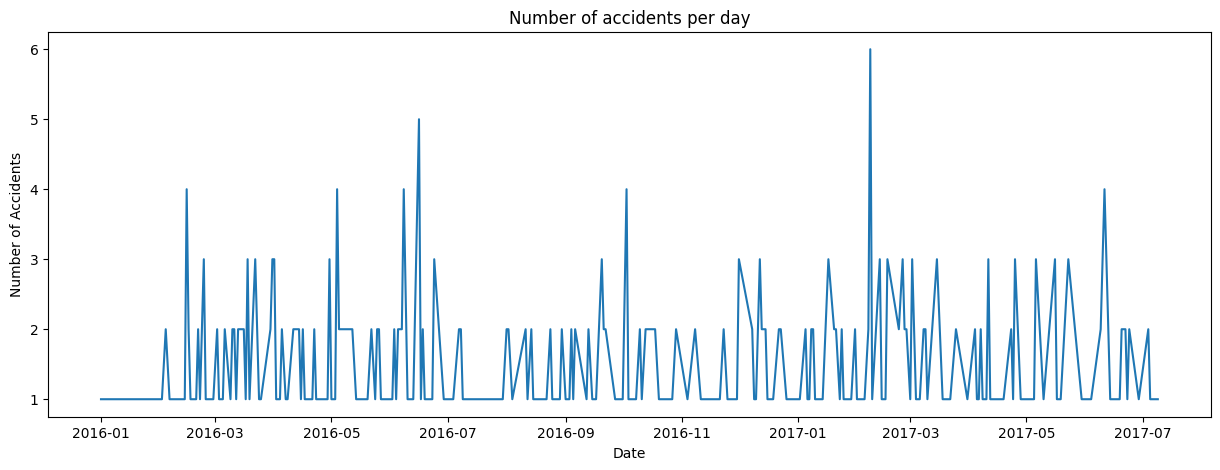

In [40]:
f, axes = plt.subplots(1,1,figsize=(15,5))
sns.lineplot(x=data_set_2['Date'].value_counts().index, y=data_set_2['Date'].value_counts().values, ax=axes)
axes.set_title("Number of accidents per day")
plt.xlabel("Date")
plt.ylabel("Number of Accidents")
plt.show()